In [6]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import warnings

from SharedModules import input_dir, output_dir, model_dir
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

cv = KFold(n_splits=10, shuffle=True, random_state=42)
scaler = StandardScaler()

_train = pd.read_csv(input_dir + "train.csv", index_col=0)
_test = pd.read_csv(input_dir + "test.csv", index_col=0)

target = "Heart Disease"

X = _train.drop(target, axis= 1)
y = _train[target].map({"Absence": 0, "Presence": 1})
X_test = _test



fold 1


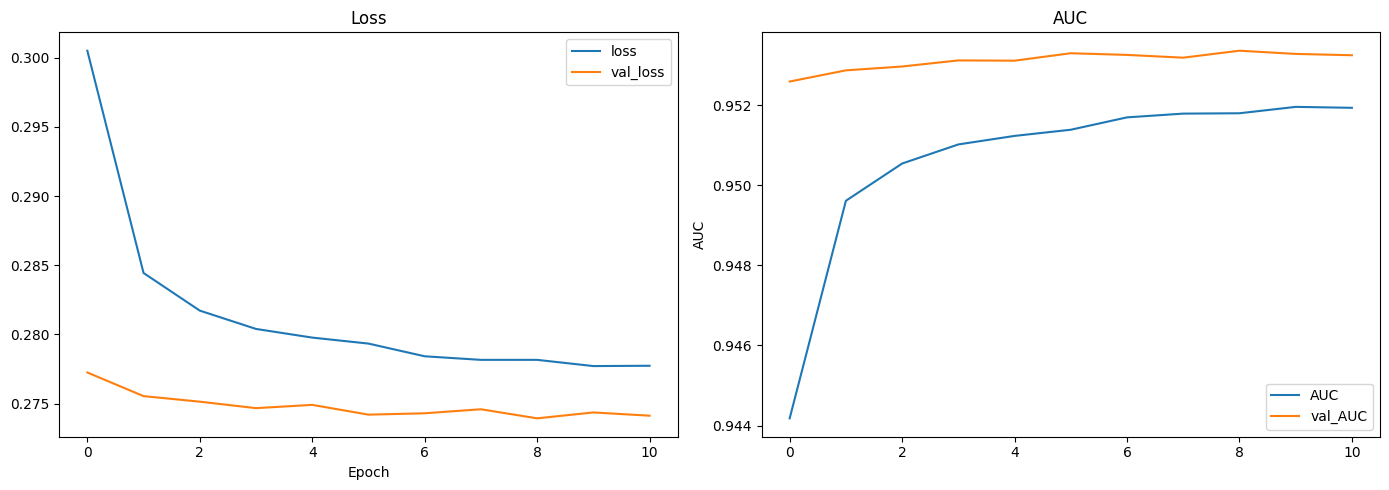

Best Validation Loss: 0.2739
Best Validation Accuracy: 0.9534
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 1s 518us/step


fold 2


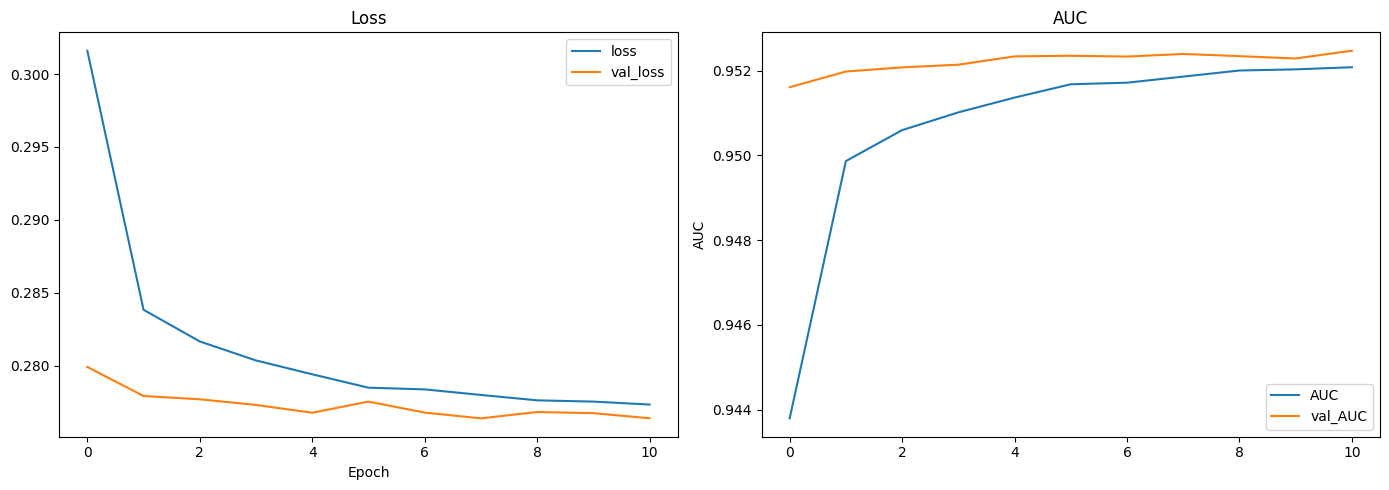

Best Validation Loss: 0.2764
Best Validation Accuracy: 0.9525
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 1s 525us/step


fold 3


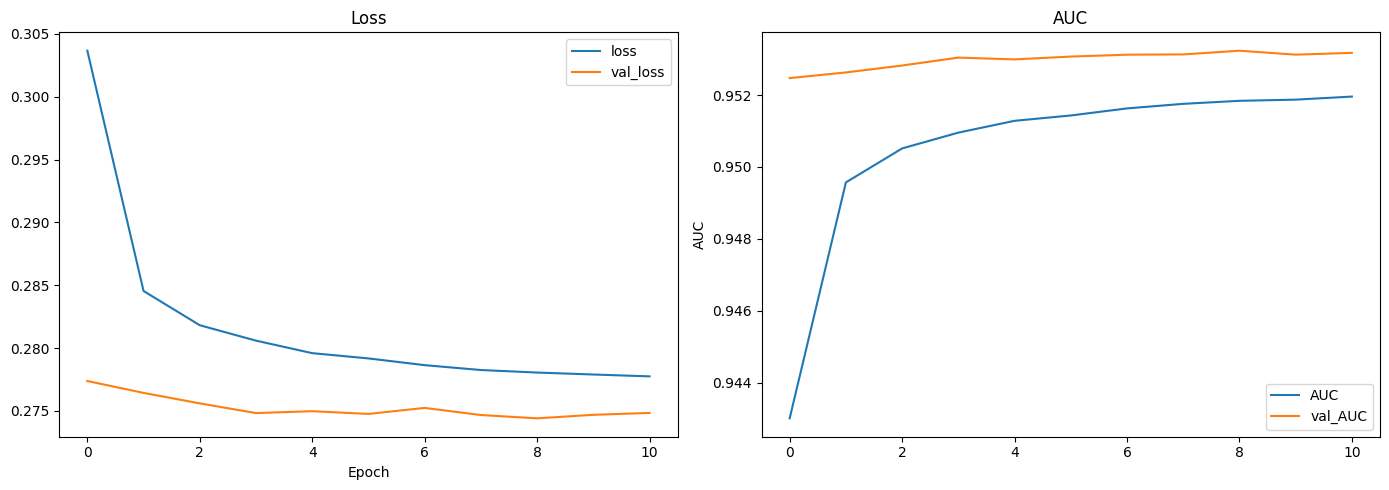

Best Validation Loss: 0.2744
Best Validation Accuracy: 0.9532
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 1s 528us/step


fold 4


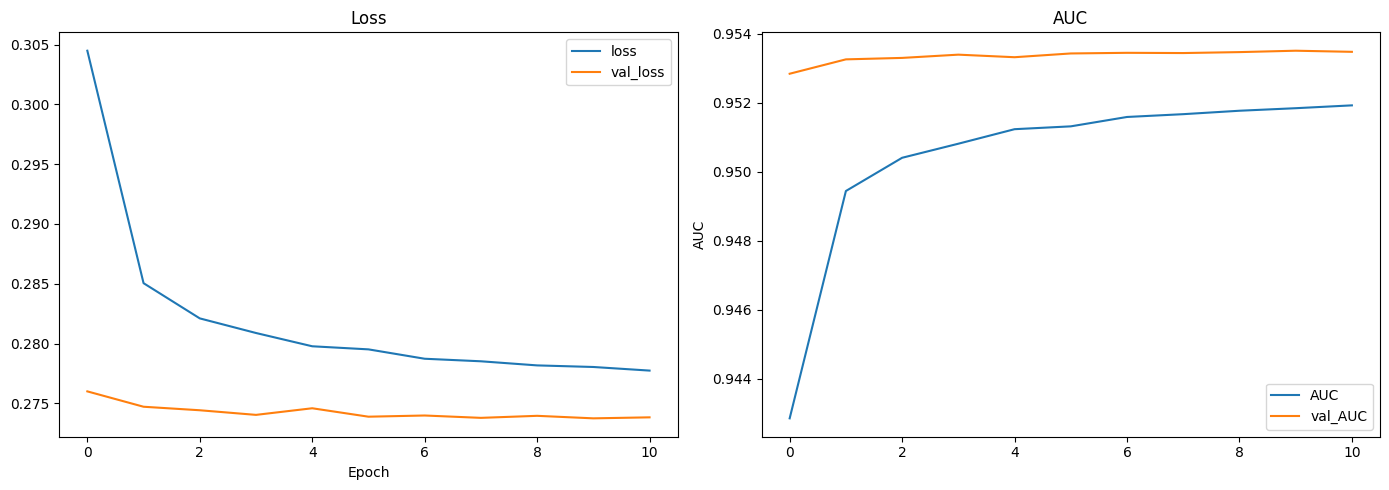

Best Validation Loss: 0.2737
Best Validation Accuracy: 0.9535
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 1s 526us/step


fold 5


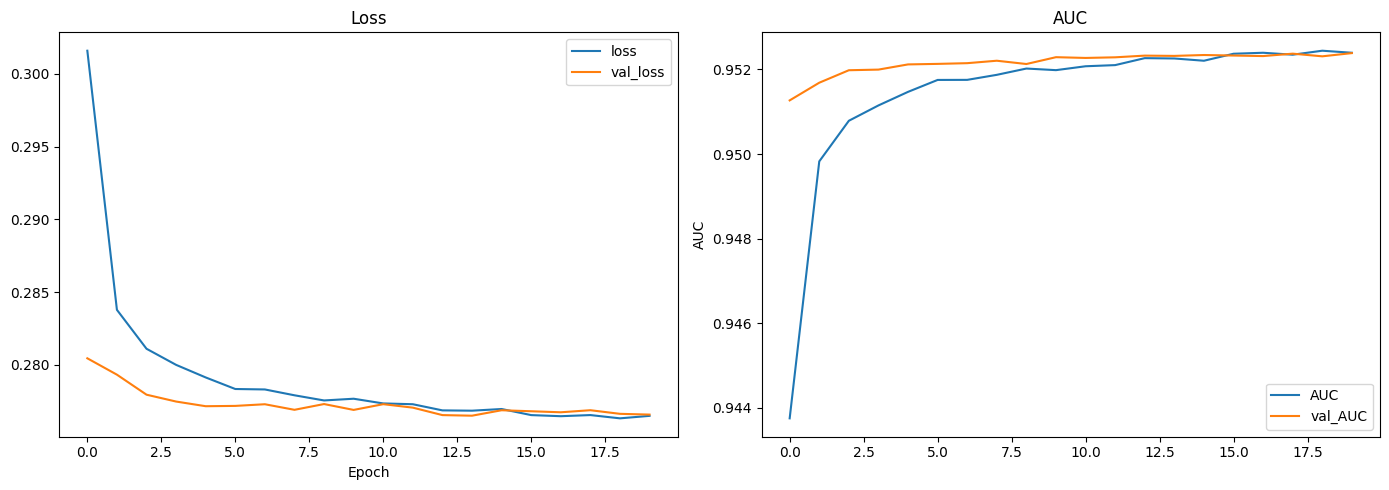

Best Validation Loss: 0.2765
Best Validation Accuracy: 0.9524
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 1s 522us/step


fold 6


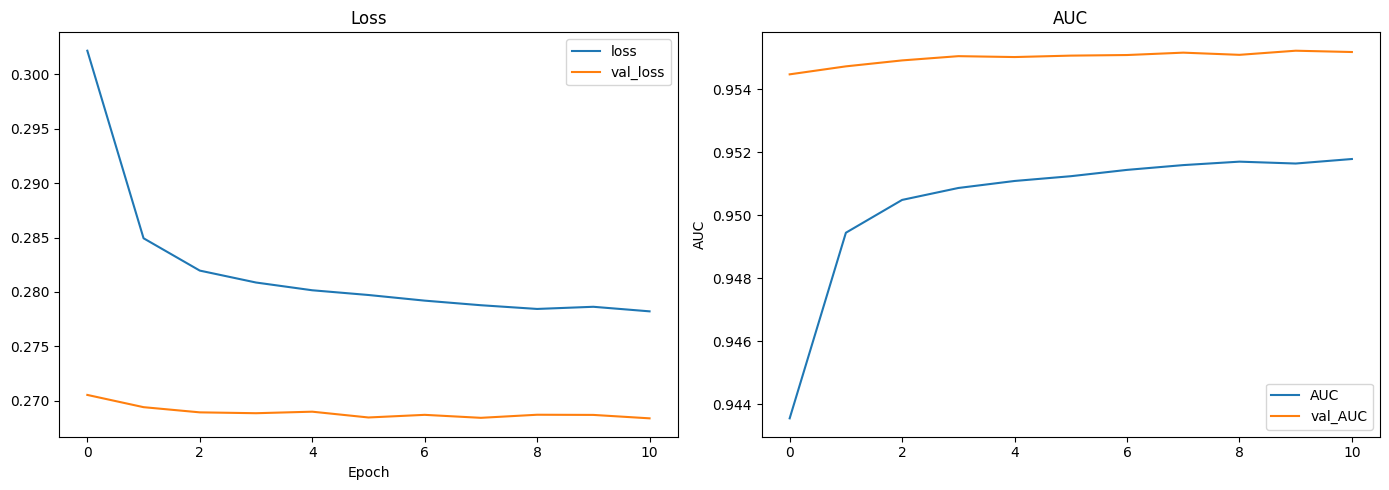

Best Validation Loss: 0.2684
Best Validation Accuracy: 0.9552
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 1s 527us/step


fold 7


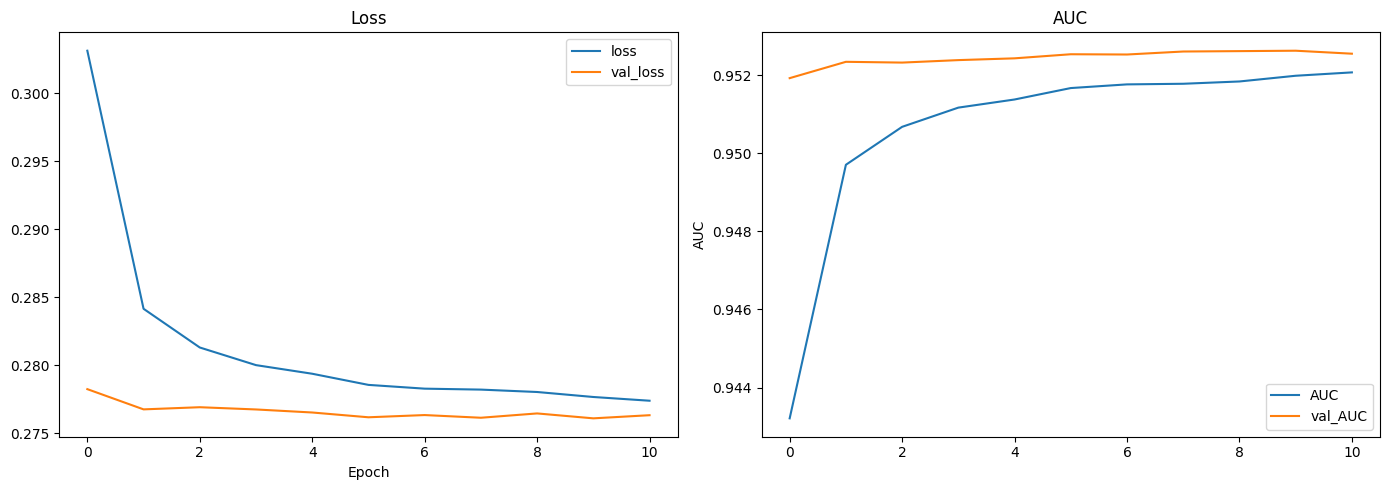

Best Validation Loss: 0.2761
Best Validation Accuracy: 0.9526
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 1s 515us/step


fold 8


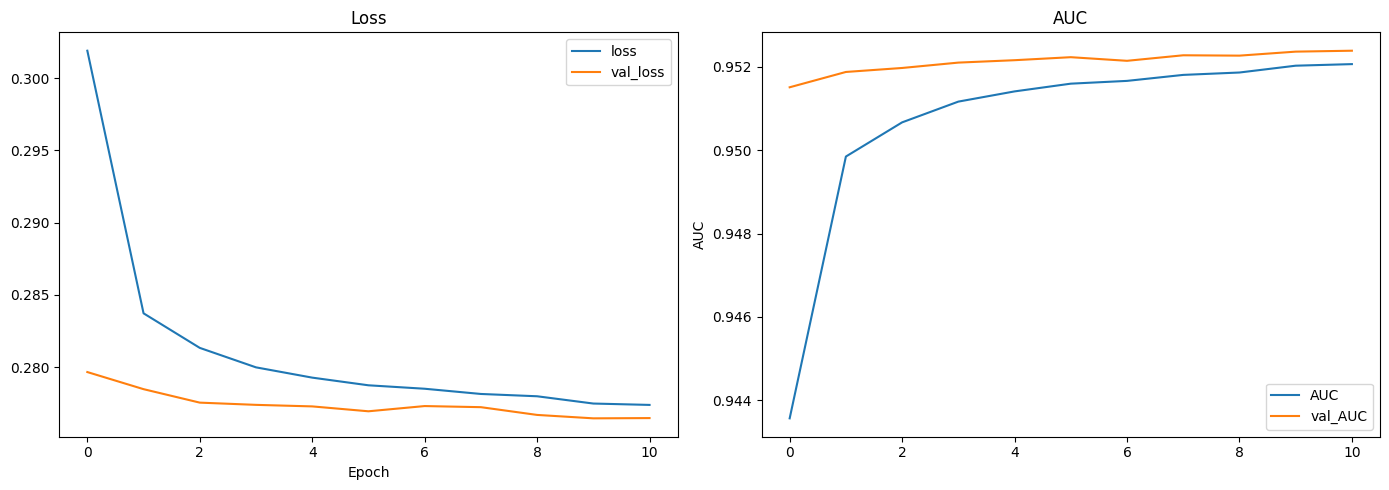

Best Validation Loss: 0.2765
Best Validation Accuracy: 0.9524
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 1s 526us/step


fold 9


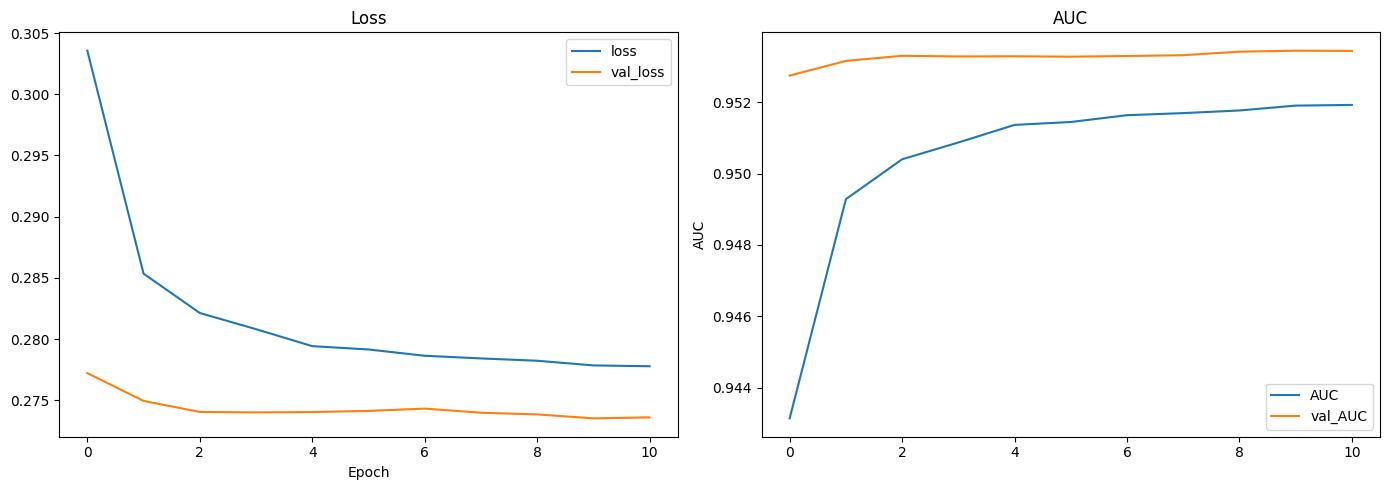

Best Validation Loss: 0.2735
Best Validation Accuracy: 0.9534
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 1s 524us/step


fold 10


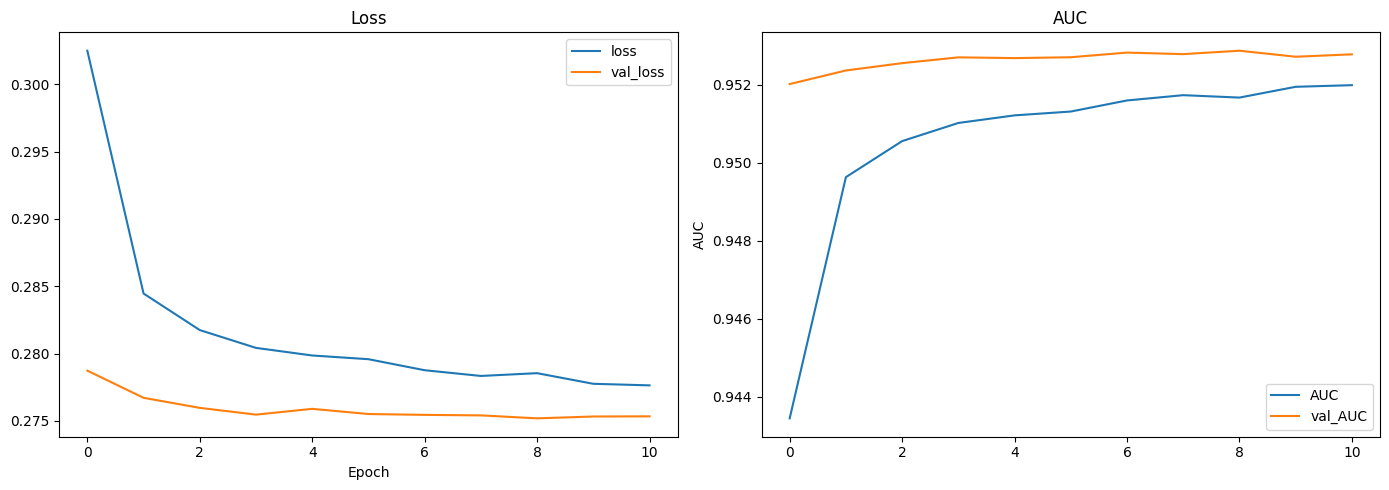

Best Validation Loss: 0.2752
Best Validation Accuracy: 0.9529
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 1s 529us/step
Average Score:  0.9532


In [ ]:
keras = tf.keras
layers = keras.layers


def build_model(n_features, units=128):
    model = keras.Sequential(
        [
            layers.Dense(units, activation="relu", input_shape=[n_features]),
            layers.BatchNormalization(),
            layers.Dropout(0.2),
            layers.Dense(units, activation="relu"),
            layers.BatchNormalization(),
            layers.Dropout(0.2),
            layers.Dense(units // 2, activation="relu"),
            layers.BatchNormalization(),
            layers.Dropout(0.2),
            layers.Dense(units // 2, activation="relu"),
            layers.BatchNormalization(),
            layers.Dropout(0.2),
            layers.Dense(1, activation="sigmoid"),
        ]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-4),
        loss="binary_crossentropy",
        metrics=["AUC"],
    )

    return model


oof = np.zeros(len(X))
oof_scores = []

for fold, (idx_tr, idx_val) in enumerate(cv.split(X, y)):
    print(f"\n\nfold {fold + 1}")
    X_tr, X_val = X.iloc[idx_tr], X.iloc[idx_val]
    y_tr, y_val = y.iloc[idx_tr], y.iloc[idx_val]

    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)

    model = build_model(X.shape[1], 256)

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_AUC",
        mode="max",
        patience=10,
        min_delta=0.001,
        restore_best_weights=True,
    )

    history = model.fit(
        X_tr_scaled,
        y_tr,
        validation_data=(X_val_scaled, y_val),
        batch_size=512,
        epochs=1000,
        callbacks=[early_stopping],
        verbose=0,
    )

    df_hist = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    df_hist.loc[:, ["loss", "val_loss"]].plot(ax=axes[0])
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    df_hist.loc[:, ["AUC", "val_AUC"]].plot(ax=axes[1])
    axes[1].set_title("AUC")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f"Best Validation Loss: {df_hist['val_loss'].min():0.4f}" + f"\nBest Validation Accuracy: {df_hist['val_AUC'].max():0.4f}")

    y_pred = model.predict(X_val_scaled).ravel()

    oof[idx_val] = y_pred
    oof_scores.append(df_hist["val_AUC"].max())

print(f"Average Score: {np.mean(oof_scores): .4f}")

df_oof = pd.DataFrame(data=oof, index=X.index, columns=["Keras"])
df_oof.to_csv(model_dir + "Keras/oof.csv")

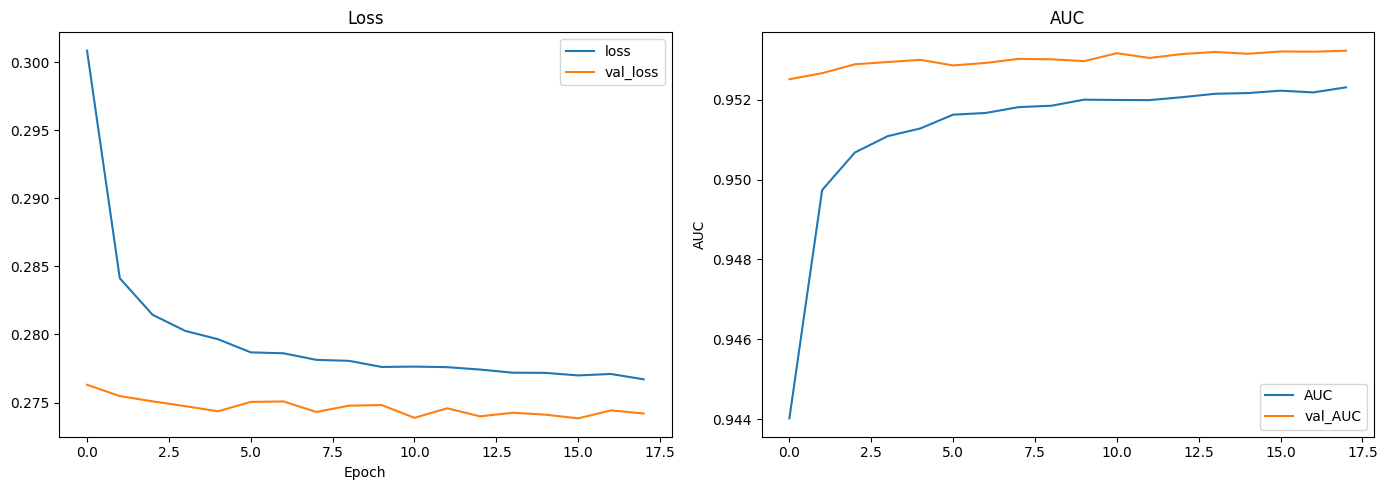

Best Validation Loss: 0.2738
Best Validation Accuracy: 0.9532
8438/8438 ━━━━━━━━━━━━━━━━━━━━ 4s 501us/step


In [8]:
final_model = build_model(X.shape[1], 256)

X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

history = final_model.fit(
    X_scaled,
    y,
    validation_split=0.1,
    batch_size=512,
    epochs=1000,
    callbacks=[early_stopping],
    verbose=0,
)

df_hist = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_hist.loc[:, ["AUC", "val_AUC"]].plot(ax=axes[1])
axes[1].set_title("AUC")
axes[1].set_ylabel("AUC")
axes[1].legend()

df_hist.loc[:, ["loss", "val_loss"]].plot(ax=axes[0])
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

plt.tight_layout()
plt.show()

print(f"Best Validation Loss: {df_hist['val_loss'].min():0.4f}" + f"\nBest Validation Accuracy: {df_hist['val_AUC'].max():0.4f}")

sub = pd.DataFrame(data=final_model.predict(X_test_scaled).squeeze(), index=X_test.index, columns=["Keras"])
sub.to_csv(output_dir + "submission_keras.csv")